C:\Users\b_o_x\AppData\Local\Temp\ipykernel_5860\3687859124.py:118: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  datos_clientes = pd.read_sql(consulta_sql, conexion)


Clientes usados en el modelo: 36654

Resultados método del codo con hiperparámetros:
   experimento       init  n_init  max_iter      tol   k        inercia
0           E1  k-means++      10       300  0.00010   1  293232.000000
1           E1  k-means++      10       300  0.00010   2  210612.872752
2           E1  k-means++      10       300  0.00010   3  149434.032727
3           E1  k-means++      10       300  0.00010   4  125467.850668
4           E1  k-means++      10       300  0.00010   5  101556.505990
5           E1  k-means++      10       300  0.00010   6   85754.811206
6           E1  k-means++      10       300  0.00010   7   74826.231524
7           E1  k-means++      10       300  0.00010   8   67819.791970
8           E1  k-means++      10       300  0.00010   9   61135.543986
9           E1  k-means++      10       300  0.00010  10   54938.465707
10          E2  k-means++      20       300  0.00010   1  293232.000000
11          E2  k-means++      20       300  0.0001

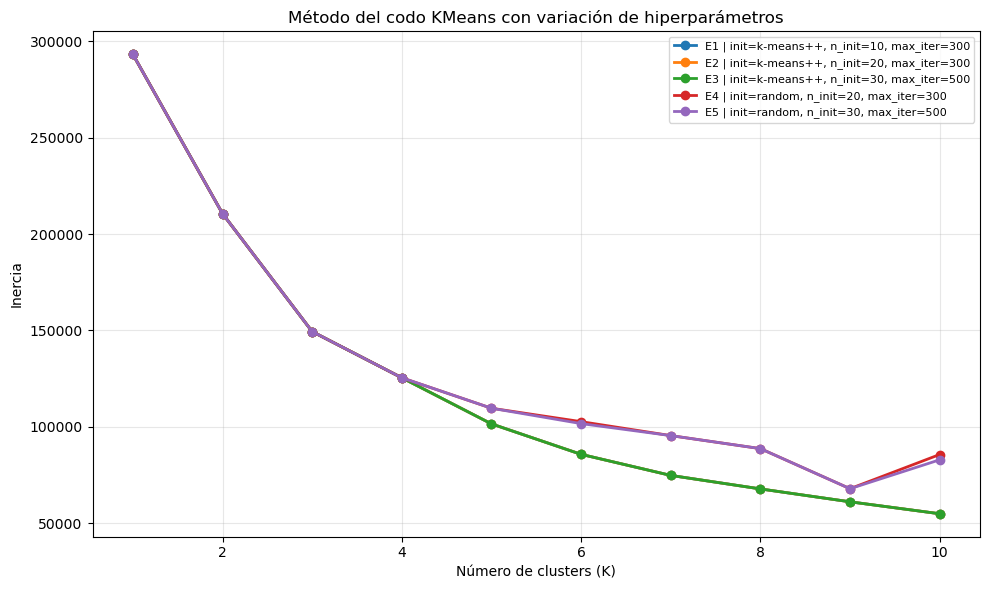


Modelo final:
Clusters: 3
Init: k-means++
n_init: 30
max_iter: 500
tol: 0.0001
Inercia final: 149434.03092804184

Distribución de clientes por cluster:
cluster
0    31973
1     3617
2     1064
Name: count, dtype: int64

Promedios por cluster:
              edad  frecuencia_compra    gasto_total  ticket_promedio  \
cluster                                                                 
0        47.384668           1.422263   18327.158791     12887.553256   
1        47.740669           1.326790   16931.809599     12930.108653   
2        47.669173          34.793233  451119.251626     13011.713689   

         ratio_pedidos  ratio_items  ratio_dinero  frecuencia_devoluciones  
cluster                                                                     
0             0.009388     0.002987      0.001576                 0.031308  
1             0.892616     0.587502      0.432189                 1.051147  
2             0.094662     0.054265      0.030476                 3.174812  

Arch

In [6]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =====================================================
# 1. CONEXIÓN
# =====================================================
conexion = pyodbc.connect(
    'Driver={SQL Server};'
    'Server=DESKTOP-SDA345T\\SQLEXPRESS;'
    'Database=tpcxbb_1gb;'
    'Trusted_Connection=yes;'
)

# =====================================================
# 2. QUERY
# =====================================================
consulta_sql = '''
SELECT
    ventas.id_cliente AS id_cliente,
    cli.nombre_cliente,
    cli.edad,
    cli.pais_nacimiento,
    ventas.total_pedidos AS frecuencia_compra,
    ventas.total_dinero AS gasto_total,
    ROUND(
        CASE
            WHEN ventas.total_pedidos = 0 THEN 0
            ELSE ventas.total_dinero * 1.0 / ventas.total_pedidos
        END
    , 7) AS ticket_promedio,
    ROUND(
        CASE
            WHEN ventas.total_pedidos = 0 THEN 0
            ELSE ISNULL(dev.pedidos_devueltos, 0) * 1.0 / ventas.total_pedidos
        END
    , 7) AS ratio_pedidos,
    ROUND(
        CASE
            WHEN ventas.total_items = 0 THEN 0
            ELSE ISNULL(dev.items_devueltos, 0) * 1.0 / ventas.total_items
        END
    , 7) AS ratio_items,
    ROUND(
        CASE
            WHEN ventas.total_dinero = 0 THEN 0
            ELSE ISNULL(dev.dinero_devuelto, 0) * 1.0 / ventas.total_dinero
        END
    , 7) AS ratio_dinero,
    ISNULL(dev.pedidos_devueltos, 0) AS frecuencia_devoluciones
FROM
(
    SELECT
        ss_customer_sk AS id_cliente,
        COUNT(DISTINCT ss_ticket_number) AS total_pedidos,
        COUNT(ss_item_sk) AS total_items,
        SUM(ss_net_paid) AS total_dinero
    FROM dbo.store_sales
    GROUP BY ss_customer_sk
) ventas
LEFT JOIN
(
    SELECT
        sr_customer_sk AS id_cliente,
        COUNT(DISTINCT sr_ticket_number) AS pedidos_devueltos,
        COUNT(sr_item_sk) AS items_devueltos,
        SUM(sr_return_amt) AS dinero_devuelto
    FROM dbo.store_returns
    GROUP BY sr_customer_sk
) dev
    ON ventas.id_cliente = dev.id_cliente
LEFT JOIN
(
    SELECT
        base.id_cliente,
        base.nombre_cliente,
        base.pais_nacimiento,
        CASE
            WHEN base.fecha_nacimiento IS NOT NULL
            THEN DATEDIFF(YEAR, base.fecha_nacimiento, GETDATE())
                 - CASE
                     WHEN DATEADD(
                         YEAR,
                         DATEDIFF(YEAR, base.fecha_nacimiento, GETDATE()),
                         base.fecha_nacimiento
                     ) > CAST(GETDATE() AS date)
                     THEN 1
                     ELSE 0
                   END
            ELSE NULL
        END AS edad
    FROM
    (
        SELECT
            c_customer_sk AS id_cliente,
            CONCAT_WS(' ', c_first_name, c_last_name) AS nombre_cliente,
            c_birth_country AS pais_nacimiento,
            TRY_CONVERT(
                date,
                CONCAT(
                    c_birth_year + 20, '-',
                    RIGHT('00' + CAST(c_birth_month AS varchar(2)), 2), '-',
                    RIGHT('00' + CAST(c_birth_day AS varchar(2)), 2)
                )
            ) AS fecha_nacimiento
        FROM dbo.customer
    ) base
) cli
    ON ventas.id_cliente = cli.id_cliente
'''

# =====================================================
# 3. CARGA Y PREPARACIÓN
# =====================================================
datos_clientes = pd.read_sql(consulta_sql, conexion)

columnas_modelo = [
    "edad",
    "frecuencia_compra",
    "gasto_total",
    "ticket_promedio",
    "ratio_pedidos",
    "ratio_items",
    "ratio_dinero",
    "frecuencia_devoluciones"
]

datos_modelo = datos_clientes[columnas_modelo].copy()
datos_modelo = datos_modelo.dropna()

escalador = StandardScaler()
datos_escalados = escalador.fit_transform(datos_modelo)

print("Clientes usados en el modelo:", len(datos_modelo))

# =====================================================
# 4. EXPERIMENTACIÓN CON MÉTODO DEL CODO
#    Cambiando hiperparámetros del KMeans
# =====================================================
experimentos = [
    {"experimento": "E1", "init": "k-means++", "n_init": 10, "max_iter": 300, "tol": 0.0001},
    {"experimento": "E2", "init": "k-means++", "n_init": 20, "max_iter": 300, "tol": 0.0001},
    {"experimento": "E3", "init": "k-means++", "n_init": 30, "max_iter": 500, "tol": 0.0001},
    {"experimento": "E4", "init": "random",    "n_init": 20, "max_iter": 300, "tol": 0.0001},
    {"experimento": "E5", "init": "random",    "n_init": 30, "max_iter": 500, "tol": 0.00001}
]

valores_k = range(1, 11)

resultados_codo = []

for exp in experimentos:
    for k in valores_k:
        modelo = KMeans(
            n_clusters=k,
            init=exp["init"],
            n_init=exp["n_init"],
            max_iter=exp["max_iter"],
            tol=exp["tol"],
            random_state=111
        )

        modelo.fit(datos_escalados)

        resultados_codo.append({
            "experimento": exp["experimento"],
            "init": exp["init"],
            "n_init": exp["n_init"],
            "max_iter": exp["max_iter"],
            "tol": exp["tol"],
            "k": k,
            "inercia": modelo.inertia_
        })

resultados_codo_df = pd.DataFrame(resultados_codo)

print("\nResultados método del codo con hiperparámetros:")
print(resultados_codo_df)

# =====================================================
# 5. GRÁFICO DEL CODO POR EXPERIMENTO
# =====================================================
plt.figure(figsize=(10, 6))

for exp in resultados_codo_df["experimento"].unique():
    datos_exp = resultados_codo_df[resultados_codo_df["experimento"] == exp]

    etiqueta = (
        exp
        + " | init=" + str(datos_exp["init"].iloc[0])
        + ", n_init=" + str(datos_exp["n_init"].iloc[0])
        + ", max_iter=" + str(datos_exp["max_iter"].iloc[0])
    )

    plt.plot(
        datos_exp["k"],
        datos_exp["inercia"],
        marker="o",
        linewidth=2,
        label=etiqueta
    )

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo KMeans con variación de hiperparámetros")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("codo_kmeans_hiperparametros.png", dpi=300)
plt.show()

# =====================================================
# 6. SELECCIÓN FINAL MANUAL SEGÚN CODO
#    Cambia este valor según el gráfico
# =====================================================
cantidad_clusters = 3

modelo_final = KMeans(
    n_clusters=cantidad_clusters,
    init="k-means++",
    n_init=30,
    max_iter=500,
    tol=0.0001,
    random_state=111
)

modelo_final.fit(datos_escalados)

datos_resultado = datos_clientes.loc[datos_modelo.index].copy()
datos_resultado["cluster"] = modelo_final.labels_

# =====================================================
# 7. RESULTADOS FINALES
# =====================================================
print("\nModelo final:")
print("Clusters:", cantidad_clusters)
print("Init: k-means++")
print("n_init: 30")
print("max_iter: 500")
print("tol: 0.0001")
print("Inercia final:", modelo_final.inertia_)

print("\nDistribución de clientes por cluster:")
print(datos_resultado["cluster"].value_counts().sort_index())

print("\nPromedios por cluster:")
perfil_clusters = datos_resultado.groupby("cluster")[columnas_modelo].mean()
print(perfil_clusters)

# =====================================================
# 8. EXPORTAR EVIDENCIA
# =====================================================
resultados_codo_df.to_excel("resultados_codo_kmeans_hiperparametros.xlsx", index=False)
datos_resultado.to_excel("clientes_segmentados_kmeans.xlsx", index=False)
perfil_clusters.to_excel("perfil_clusters_kmeans.xlsx")

print("\nArchivos generados:")
print("codo_kmeans_hiperparametros.png")
print("resultados_codo_kmeans_hiperparametros.xlsx")
print("clientes_segmentados_kmeans.xlsx")
print("perfil_clusters_kmeans.xlsx")

conexion.close()